# 0. 환경 설정

In [1]:
import torch

print("CUDA 사용 가능 여부:", torch.cuda.is_available())
print("사용 중인 디바이스:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")
print("GPU 이름:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음")


CUDA 사용 가능 여부: True
사용 중인 디바이스: 0
GPU 이름: NVIDIA A100 80GB PCIe


# 1. EDA

In [3]:
import pandas as pd
import numpy as np

# 24시간 동안 100ms 주기로 생성: 24h * 60m * 60s * 10 = 864000 rows
timestamps = pd.date_range(start='2025-07-30 00:00:00', periods=24*60*60*10, freq='100ms')

# 랜덤 트래픽 데이터 생성 (예시)
np.random.seed(42)
tcp = np.random.poisson(lam=5, size=len(timestamps))
udp = np.random.poisson(lam=3, size=len(timestamps))
pkt = tcp + udp + np.random.poisson(lam=2, size=len(timestamps))
traffic = pkt * np.random.uniform(100, 1500, size=len(timestamps))

df = pd.DataFrame({
    'timestamp': timestamps,
    'tcp_pkt_count': tcp,
    'udp_pkt_count': udp,
    'pkt_count': pkt,
    'traffic_volume': traffic
})

# CSV로 저장
csv_path = './data/network_100ms_24h.csv'
df.to_csv(csv_path, index=False)

# 사용자에게 미리보기 제공
df.head(10)


,timestamp,tcp_pkt_count,udp_pkt_count,pkt_count,traffic_volume
0,2025-07-30 00:00:00.000,5,2,10,2208.914565
1,2025-07-30 00:00:00.100,4,2,9,6365.369768
2,2025-07-30 00:00:00.200,4,2,7,6762.770840
3,2025-07-30 00:00:00.300,5,5,14,1786.050110
4,2025-07-30 00:00:00.400,5,4,10,13244.992054
5,2025-07-30 00:00:00.500,3,6,11,7570.661665
6,2025-07-30 00:00:00.600,5,3,12,14152.367830
7,2025-07-30 00:00:00.700,4,4,8,4076.109824
8,2025-07-30 00:00:00.800,6,3,10,6306.320034
9,2025-07-30 00:00:00.900,7,3,11,1198.690949


In [4]:
# 타임스탬프 인덱스로 변환
df = df.set_index("timestamp").sort_index()

In [5]:
# 결측 / 이상치 확인
df.isna().sum()
df.describe()

,tcp_pkt_count,udp_pkt_count,pkt_count,traffic_volume
count,864000.000000,864000.000000,864000.000000,864000.000000
mean,5.000723,2.999104,10.000471,8001.610773
std,2.237181,1.732428,3.164015,4940.347681
min,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,8.000000,3996.191868
50%,5.000000,3.000000,10.000000,7260.416343
75%,6.000000,4.000000,12.000000,11202.958621
max,20.000000,16.000000,28.000000,36131.595526


In [6]:
# 피크값 라벨 생성 (1000ms 윈도우 내 최댓값)
df['peak_1000ms'] = df['traffic_volume'].rolling(window=10).max().shift(-9)

In [7]:
df # [학습전, 최종데이터에 peak_1000ms 만들어놓기!]

# 고민사항
# peak_1000ms 만들떄, rolling(window=10)으로 만들면, 마지막 9개는 Nan결측치가 생긴다. 
# 찬생각 -> 지워도될듯!! 

,tcp_pkt_count,udp_pkt_count,pkt_count,traffic_volume,peak_1000ms
timestamp,,,,,
2025-07-30 00:00:00.000,5,2,10,2208.914565,14152.36783
2025-07-30 00:00:00.100,4,2,9,6365.369768,14152.36783
2025-07-30 00:00:00.200,4,2,7,6762.770840,14152.36783
2025-07-30 00:00:00.300,5,5,14,1786.050110,14152.36783
2025-07-30 00:00:00.400,5,4,10,13244.992054,14152.36783
...,...,...,...,...,...
2025-07-30 23:59:59.500,4,5,10,2779.064901,NaN
2025-07-30 23:59:59.600,4,2,8,2681.976904,NaN
2025-07-30 23:59:59.700,6,8,17,23043.340730,NaN


In [8]:
print("NaN 개수 확인:")
print(df["peak_1000ms"].isna().sum())

NaN 개수 확인:
9


# 2. 데이터 전처리
- train : val : test = 60:20:20
- scaler : StandardScaler
- return : train_ds, val_ds, test_ds, scaler

In [14]:
# reload

import importlib
import preprocessing
importlib.reload(preprocessing)

<module 'preprocessing' from '/data/aisvc_data/wooribank/chan/woori/study_y/preprocessing.py'>

In [15]:
from preprocessing import preprocess_data

In [16]:
train_ds, val_ds, test_ds, scaler = preprocess_data(df)

# 3. 모델로드 + 학습 + 시각화 + 모델저장
- 이렇게 4개 세트로 다양하게 실험해보기!!

### 3-1. 모델로드

In [31]:

# importlib.realoa(model)
from model import PeakTrafficPredictor
# from torchsummary import summary  # 또는 print(model)

model = PeakTrafficPredictor(input_dim=4, hidden_dim=64).to(device)
print(model)

PeakTrafficPredictor(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


### 3-2. 학습

In [35]:
import train
importlib.reload(train)

from train import train_model

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # gpu설정
model, history = train_model(model, train_ds, val_ds, device=device, epochs=10) 

[Epoch 1] Train Loss: 228790853299.0000 | Val Loss: 17075941432.7500
[Epoch 2] Train Loss: 50848749317.0000 | Val Loss: 16816259104.2500
[Epoch 3] Train Loss: 50542484431.5000 | Val Loss: 16746873685.2500
[Epoch 4] Train Loss: 50484928400.0000 | Val Loss: 16737574809.7500
[Epoch 5] Train Loss: 50449590796.5000 | Val Loss: 16726694505.0000
[Epoch 6] Train Loss: 50442251564.0000 | Val Loss: 16729401776.2500
[Epoch 7] Train Loss: 50431918580.0000 | Val Loss: 16723565687.7500
[Epoch 8] Train Loss: 50427323549.5000 | Val Loss: 16738522505.5000
[Epoch 9] Train Loss: 50422154424.0000 | Val Loss: 16754623972.7500
[Epoch 10] Train Loss: 50419442840.5000 | Val Loss: 16756712329.5000


### 3-3. 시각화

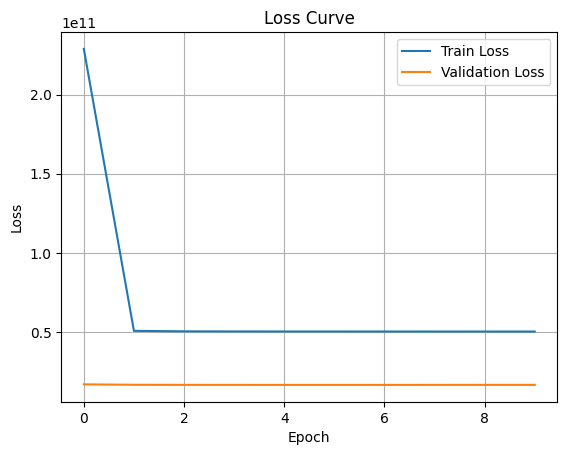

In [38]:
import matplotlib.pyplot as plt

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

### 3-4. 모델저장

In [39]:
import torch
import os

# 저장 경로 생성 (없으면 생성)
os.makedirs("outputs", exist_ok=True)

# 저장
torch.save(model.state_dict(), "outputs/peak_model_v1.pt")
print(" 모델 저장 완료: outputs/peak_model_v1.pt")

 모델 저장 완료: outputs/peak_model_v1.pt


# 4. 검증

In [40]:
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error

# 1. 테스트 데이터 준비
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

# 2. 평가 모드 설정
model.eval()

PeakTrafficPredictor(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [41]:
# 3. 예측 및 정답 저장
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()   # 예측값
        labels = yb.numpy()               # 실제값

        all_preds.extend(preds)
        all_labels.extend(labels)


In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(all_labels, all_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_labels, all_preds)
r2 = r2_score(all_labels, all_preds)

print(f"📊 Test MSE  : {mse:.4f}")
print(f"📊 Test RMSE : {rmse:.4f}")
print(f"📊 Test MAE  : {mae:.4f}")
print(f"📊 Test R²   : {r2:.4f}")


📊 Test MSE  : 12263377.0000
📊 Test RMSE : 3501.9104
📊 Test MAE  : 2722.4185
📊 Test R²   : 0.0773
